# **INSTALLING LIBRARIES:**

In [79]:
%pip install datasets
%pip install transformers
%pip install spacy
%pip install torch
%pip install spacy-transformers
%pip install transformers[torch]
%pip install seqeval

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# **DATASET LOADING:**

**Loading and splitting the dataset into train, test and validation:**

In [80]:
from datasets import load_dataset, load_metric
dataset = load_dataset("surrey-nlp/PLOD-CW")

In [81]:
train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

# **TOKENISATION:**

**Defining the pretrained BERT tokenizer:**

In [82]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [83]:
tokenized_input = tokenizer(train_dataset["tokens"], is_split_into_words=True)

for token in tokenized_input["input_ids"]:
    print(tokenizer.convert_ids_to_tokens(token))
    break

Token indices sequence length is longer than the specified maximum sequence length for this model (542 > 512). Running this sequence through the model will result in indexing errors


['[CLS]', 'for', 'this', 'purpose', 'the', 'gothenburg', 'young', 'persons', 'empowerment', 'scale', '(', 'g', '##ype', '##s', ')', 'was', 'developed', '.', '[SEP]']


**Label encoding the ner_tags:**

In [84]:
label_encoding = {"B-O": 0, "B-AC": 1, "B-LF": 2, "I-LF": 3}

label_list = []
for sample in train_dataset["ner_tags"]:
    label_list.append([label_encoding[tag] for tag in sample])

val_label_list = []
for sample in val_dataset["ner_tags"]:
    val_label_list.append([label_encoding[tag] for tag in sample])

test_label_list = []
for sample in test_dataset["ner_tags"]:
    test_label_list.append([label_encoding[tag] for tag in sample])

**Function to tokenize the data:**

In [85]:
def tokenize_and_align_labels(train_dataset, list_name):
    tokenized_inputs = tokenizer(train_dataset["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(list_name):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100) #Appending -100 to the special tokens
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [86]:
tokenized_train_datasets = tokenize_and_align_labels(train_dataset, label_list)
tokenized_val_datasets = tokenize_and_align_labels(val_dataset, val_label_list)
tokenized_test_datasets = tokenize_and_align_labels(test_dataset, test_label_list)

In [87]:
def turn_dict_to_list_of_dict(d):
    new_list = []

    for labels, inputs in zip(d["labels"], d["input_ids"]):
        entry = {"input_ids": inputs, "labels": labels}
        new_list.append(entry)

    return new_list

In [88]:
tokenised_train = turn_dict_to_list_of_dict(tokenized_train_datasets)
tokenised_val = turn_dict_to_list_of_dict(tokenized_val_datasets)
tokenised_test = turn_dict_to_list_of_dict(tokenized_test_datasets)

In [89]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer)

**Defining the evaluation:**

In [90]:
import numpy as np

metric = load_metric("seqeval")
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

/user/HS402/jj01056/.local/lib/python3.10/site-packages/datasets/load.py:759: FutureWarning: The repository for seqeval contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.19.0/metrics/seqeval/seqeval.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


# **Transformer Model:**

**Model building and execution:**

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Definning the transformer model:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(input_dim, hidden_dim)
        self.transformer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4)
        self.encoder = nn.TransformerEncoder(self.transformer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = embedded.permute(1, 0, 2)
        out = self.encoder(embedded)
        out = out.permute(1, 0, 2)
        out = self.fc(out)
        return out
#-------------------------------------------------------------------------------------------------------

# Converting the  tokenized data to PyTorch tensors for the model to be fed an input:
def convert_to_tensors(tokenized_data):
    input_ids = torch.tensor(tokenized_data['input_ids'])
    labels = torch.tensor(tokenized_data['labels'])
    return input_ids, labels


train_data = [convert_to_tensors(batch) for batch in tokenised_train]
val_data = [convert_to_tensors(batch) for batch in tokenised_val]
test_data = [convert_to_tensors(batch) for batch in tokenised_test]
#--------------------------------------------------------------------------------------------------------

# Padding the data sequences within each batch:
def pad_collate(batch):
    (xx, yy) = zip(*batch)
    x_lens = [len(x) for x in xx]
    y_lens = [len(y) for y in yy]
    xx_pad = torch.nn.utils.rnn.pad_sequence(xx, batch_first=True, padding_value=0)
    yy_pad = torch.nn.utils.rnn.pad_sequence(yy, batch_first=True, padding_value=-100)
    return xx_pad, yy_pad
#--------------------------------------------------------------------------------------------------------

# Create DataLoader for train, validation, and test sets:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=pad_collate)
val_loader = DataLoader(val_data, batch_size=32, collate_fn=pad_collate)
test_loader = DataLoader(test_data, batch_size=32, collate_fn=pad_collate)
#--------------------------------------------------------------------------------------------------------

# Defining the parameters for the model:
input_dim = 500000
hidden_dim = 128
output_dim = 4
num_layers = 2
num_epochs = 10
learning_rate = 0.001
#--------------------------------------------------------------------------------------------------------

# Initialize model, loss, and optimizer
model = TransformerModel(input_dim, hidden_dim, output_dim, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#--------------------------------------------------------------------------------------------------------
# Training and validating the model:
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs.transpose(1, 2), labels)
        loss.backward()
        optimizer.step()

    # Model validation:
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.transpose(1, 2), labels).item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(val_loader):.4f}')

# Testing the model:
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for input_ids, labels in test_loader:
        outputs = model(input_ids)
        test_loss += criterion(outputs.transpose(1, 2), labels).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/10], Validation Loss: 0.7073
Epoch [2/10], Validation Loss: 0.6360
Epoch [3/10], Validation Loss: 0.6036
Epoch [4/10], Validation Loss: 0.5582
Epoch [5/10], Validation Loss: 0.5510
Epoch [6/10], Validation Loss: 0.5299
Epoch [7/10], Validation Loss: 0.5529
Epoch [8/10], Validation Loss: 0.5449
Epoch [9/10], Validation Loss: 0.5602
Epoch [10/10], Validation Loss: 0.5345
Test Loss: 0.5583


**Evaluation Metrics:**

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate_model(model, data_loader, mode='validation'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"{mode.capitalize()} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()

    return accuracy, precision, recall, f1, all_preds, all_labels

train_accuracy_tnf, train_precision_tnf, train_recall_tnf, train_f1_tnf, train_preds, train_labels = evaluate_model(model, train_loader, mode='train')
val_accuracy_tnf, val_precision_tnf, val_recall_tnf, val_f1_tnf, val_preds, val_labels = evaluate_model(model, val_loader, mode='validation')
test_accuracy_tnf, test_precision_tnf, test_recall_tnf, test_f1_tnf, test_preds, test_labels = evaluate_model(model, test_loader, mode='test')


print("Test Classification Report:")
print(classification_report(test_labels, test_preds, zero_division=0))


Train Metrics:
Accuracy: 0.2786
Precision: 0.3216
Recall: 0.5197
F1-score: 0.3773

Validation Metrics:
Accuracy: 0.2354
Precision: 0.2387
Recall: 0.3973
F1-score: 0.2696

Test Metrics:
Accuracy: 0.3255
Precision: 0.2442
Recall: 0.3659
F1-score: 0.2736

Test Classification Report:
              precision    recall  f1-score   support

        -100       0.00      0.00      0.00      9748
           0       0.33      0.91      0.48      5397
           1       0.42      0.52      0.47       547
           2       0.25      0.15      0.18       300
           3       0.22      0.26      0.24       407

    accuracy                           0.33     16399
   macro avg       0.24      0.37      0.27     16399
weighted avg       0.13      0.33      0.18     16399



**Confusion Matrix:**

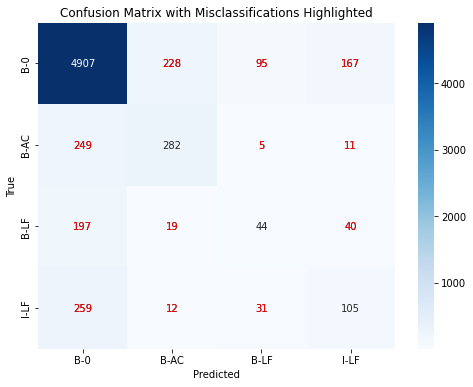

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model
def evaluate_model_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)

            # Remove tokens with value -100
            mask = labels != -100
            preds = preds[mask]
            labels = labels[mask]

            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    return all_labels, all_preds

# Evaluate on test set
test_labels, test_preds = evaluate_model_confusion_matrix(model, test_loader)

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Define labels for confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']  # Modify based on your label scheme

# Plot confusion matrix with misclassifications highlighted
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)

# Highlight misclassifications
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            plt.text(j + 0.5, i + 0.5, cm[i, j], color='red', ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Misclassifications Highlighted')
plt.show()


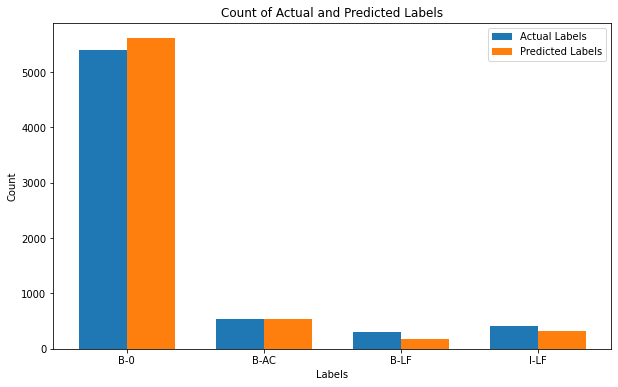

In [95]:
import matplotlib.pyplot as plt

# Ensure labels are in the same order as in the confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']

# Count of actual labels for each unique label
actual_label_count = {label: test_labels.count(idx) for idx, label in enumerate(labels)}

# Count of predicted labels for each unique label
predicted_label_count = {label: test_preds.count(idx) for idx, label in enumerate(labels)}

# Plot the counts
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(labels))

actual_bars = ax.bar(index, actual_label_count.values(), bar_width, label='Actual Labels')
predicted_bars = ax.bar(index + bar_width, predicted_label_count.values(), bar_width, label='Predicted Labels')

ax.set_xlabel('Labels')
ax.set_ylabel('Count')
ax.set_title('Count of Actual and Predicted Labels')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


In [96]:
def get_mispredicted_pairs(confusion_matrix, labels):
    mispredicted_pairs = []

    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and confusion_matrix[i, j] > 0:
                mispredicted_pairs.append((labels[i], labels[j], confusion_matrix[i, j]))

    return mispredicted_pairs

# Example usage
mispredicted_pairs = get_mispredicted_pairs(cm, labels)
for pair in mispredicted_pairs:
    print(f"Mispredicted: {pair[0]} as {pair[1]} - Count: {pair[2]}")


Mispredicted: B-0 as B-AC - Count: 228
Mispredicted: B-0 as B-LF - Count: 95
Mispredicted: B-0 as I-LF - Count: 167
Mispredicted: B-AC as B-0 - Count: 249
Mispredicted: B-AC as B-LF - Count: 5
Mispredicted: B-AC as I-LF - Count: 11
Mispredicted: B-LF as B-0 - Count: 197
Mispredicted: B-LF as B-AC - Count: 19
Mispredicted: B-LF as I-LF - Count: 40
Mispredicted: I-LF as B-0 - Count: 259
Mispredicted: I-LF as B-AC - Count: 12
Mispredicted: I-LF as B-LF - Count: 31


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

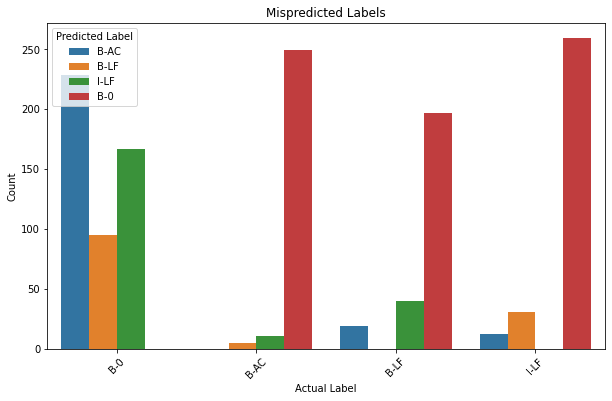

In [97]:
import pandas as pd

mispredicted_df = pd.DataFrame(mispredicted_pairs, columns=['Actual', 'Predicted', 'Count'])

# Plot mispredicted pairs
plt.figure(figsize=(10, 6))
sns.barplot(x='Actual', y='Count', hue='Predicted', data=mispredicted_df)
plt.title('Mispredicted Labels')
plt.xlabel('Actual Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Predicted Label')
plt.show()


Epoch [1/10], Validation Loss: 0.5893, Test Accuracy: 0.3153
Epoch [2/10], Validation Loss: 0.5642, Test Accuracy: 0.3198
Epoch [3/10], Validation Loss: 0.5806, Test Accuracy: 0.3240
Epoch [4/10], Validation Loss: 0.5832, Test Accuracy: 0.3239
Epoch [5/10], Validation Loss: 0.6236, Test Accuracy: 0.3181
Epoch [6/10], Validation Loss: 0.6189, Test Accuracy: 0.3220
Epoch [7/10], Validation Loss: 0.6445, Test Accuracy: 0.3184
Epoch [8/10], Validation Loss: 0.6887, Test Accuracy: 0.3209
Epoch [9/10], Validation Loss: 0.7096, Test Accuracy: 0.3200
Epoch [10/10], Validation Loss: 0.7427, Test Accuracy: 0.3179


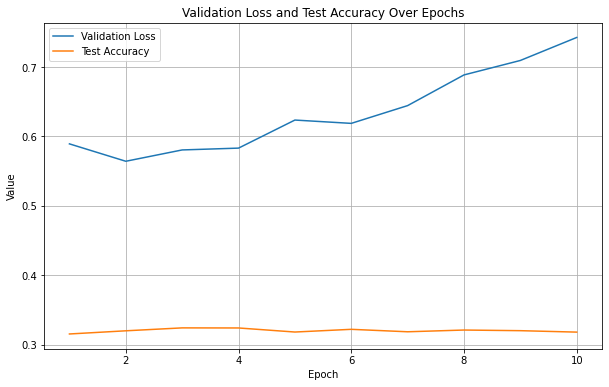

In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

validation_losses = []
test_accuracies = []


for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs.transpose(1, 2), labels)
        loss.backward()
        optimizer.step()


    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        total_correct = 0
        total_count = 0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.transpose(1, 2), labels).item()


        validation_losses.append(val_loss / len(val_loader))


        correct = 0
        total = 0
        for input_ids, labels in test_loader:
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, dim=2)
            total += labels.size(0) * labels.size(1)
            correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        test_accuracies.append(accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {validation_losses[-1]:.4f}, Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), validation_losses, label='Validation Loss')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Validation Loss and Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


# **Bi-Directional LSTM:**

**Building and running the model:**

In [99]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Defining the BI-LSTM model:
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = self.fc(lstm_out)
        return out
#--------------------------------------------------------------------------------------------------------

# Converting tokenized data to PyTorch tensors:
def convert_to_tensors(tokenized_data):
    input_ids = torch.tensor(tokenized_data['input_ids'])
    labels = torch.tensor(tokenized_data['labels'])
    return input_ids, labels


train_data = [convert_to_tensors(batch) for batch in tokenised_train]
val_data = [convert_to_tensors(batch) for batch in tokenised_val]
test_data = [convert_to_tensors(batch) for batch in tokenised_test]
#--------------------------------------------------------------------------------------------------------

# Padding data sequences within each batch:
def pad_collate(batch):
    (xx, yy) = zip(*batch)
    # Pad input sequences
    xx_pad = torch.nn.utils.rnn.pad_sequence(xx, batch_first=True, padding_value=0)
    # Pad target labels to match the maximum sequence length
    max_seq_len = max(len(seq) for seq in xx)
    yy_pad = torch.nn.utils.rnn.pad_sequence([seq[:max_seq_len] for seq in yy], batch_first=True, padding_value=-100)
    return xx_pad, yy_pad
#--------------------------------------------------------------------------------------------------------

# Creating DataLoader for train, validation, and test sets:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, collate_fn=pad_collate)
val_loader = DataLoader(val_data, batch_size=32, collate_fn=pad_collate)
test_loader = DataLoader(test_data, batch_size=32, collate_fn=pad_collate)
#--------------------------------------------------------------------------------------------------------

# Definining the parameters for the model:
input_dim = 500000
embedding_dim = 100
hidden_dim = 128
output_dim = 4
num_epochs = 10
learning_rate = 0.001
#--------------------------------------------------------------------------------------------------------

# Initializing model, loss, and optimizer
model = BiLSTMModel(input_dim, embedding_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore padding index in loss calculation
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#--------------------------------------------------------------------------------------------------------

# Training and validating the model:
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids)

        # Calculate loss
        loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    # Model validation:
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss/len(val_loader):.4f}')
#--------------------------------------------------------------------------------------------------------
# Testing the model:
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for input_ids, labels in test_loader:
        outputs = model(input_ids)
        test_loss += criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1)).item()

print(f'Test Loss: {test_loss/len(test_loader):.4f}')


Epoch [1/10], Validation Loss: 0.6298
Epoch [2/10], Validation Loss: 0.4997
Epoch [3/10], Validation Loss: 0.4529
Epoch [4/10], Validation Loss: 0.4307
Epoch [5/10], Validation Loss: 0.4142
Epoch [6/10], Validation Loss: 0.4181
Epoch [7/10], Validation Loss: 0.3890
Epoch [8/10], Validation Loss: 0.3879
Epoch [9/10], Validation Loss: 0.4166
Epoch [10/10], Validation Loss: 0.4118
Test Loss: 0.3899


**Evaluation Metrics:**

In [100]:
def evaluate_model(model, data_loader, mode='validation'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    print(f"{mode.capitalize()} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()

    return accuracy, precision, recall, f1, all_preds, all_labels

train_accuracy_tnf, train_precision_tnf, train_recall_tnf, train_f1_tnf, train_preds, train_labels = evaluate_model(model, train_loader, mode='train')
val_accuracy_tnf, val_precision_tnf, val_recall_tnf, val_f1_tnf, val_preds, val_labels = evaluate_model(model, val_loader, mode='validation')
test_accuracy_tnf, test_precision_tnf, test_recall_tnf, test_f1_tnf, test_preds, test_labels = evaluate_model(model, test_loader, mode='test')


print("Test Classification Report:")
print(classification_report(test_labels, test_preds, zero_division=0))


Train Metrics:
Accuracy: 0.3020
Precision: 0.5646
Recall: 0.6664
F1-score: 0.5719

Validation Metrics:
Accuracy: 0.2509
Precision: 0.4358
Recall: 0.4822
F1-score: 0.4072

Test Metrics:
Accuracy: 0.3509
Precision: 0.4245
Recall: 0.4959
F1-score: 0.4275

Test Classification Report:
              precision    recall  f1-score   support

        -100       0.00      0.00      0.00      9748
           0       0.33      0.95      0.49      5397
           1       0.62      0.50      0.55       547
           2       0.54      0.41      0.46       300
           3       0.63      0.63      0.63       407

    accuracy                           0.35     16399
   macro avg       0.42      0.50      0.43     16399
weighted avg       0.16      0.35      0.20     16399



**Confusion Matrix:**

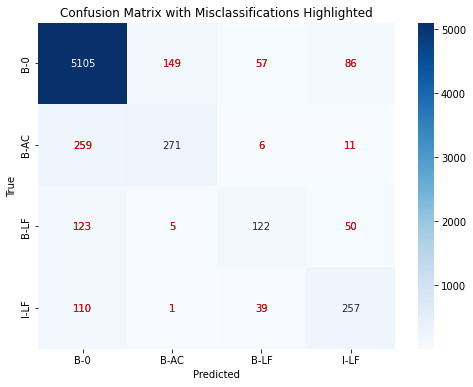

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model
def evaluate_model_confusion_matrix(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input_ids, labels in data_loader:
            outputs = model(input_ids)
            preds = torch.argmax(outputs, dim=2)

            # Remove tokens with value -100
            mask = labels != -100
            preds = preds[mask]
            labels = labels[mask]

            all_preds.extend(preds.flatten().tolist())
            all_labels.extend(labels.flatten().tolist())

    return all_labels, all_preds

# Evaluate on test set
test_labels, test_preds = evaluate_model_confusion_matrix(model, test_loader)

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Define labels for confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']  # Modify based on your label scheme

# Plot confusion matrix with misclassifications highlighted
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=labels, yticklabels=labels)

# Highlight misclassifications
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j:
            plt.text(j + 0.5, i + 0.5, cm[i, j], color='red', ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix with Misclassifications Highlighted')
plt.show()


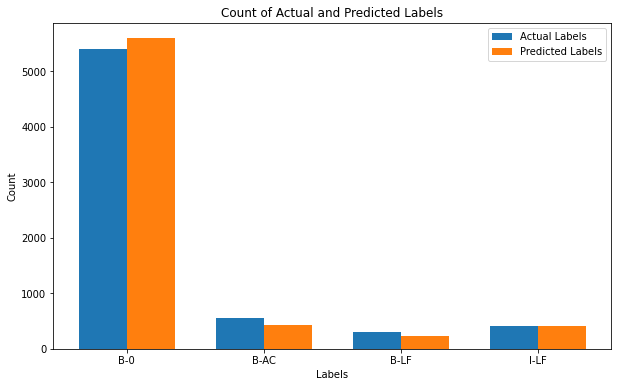

In [102]:
import matplotlib.pyplot as plt

# Ensure labels are in the same order as in the confusion matrix
labels = ['B-0', 'B-AC', 'B-LF', 'I-LF']

# Count of actual labels for each unique label
actual_label_count = {label: test_labels.count(idx) for idx, label in enumerate(labels)}

# Count of predicted labels for each unique label
predicted_label_count = {label: test_preds.count(idx) for idx, label in enumerate(labels)}

# Plot the counts
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(labels))

actual_bars = ax.bar(index, actual_label_count.values(), bar_width, label='Actual Labels')
predicted_bars = ax.bar(index + bar_width, predicted_label_count.values(), bar_width, label='Predicted Labels')

ax.set_xlabel('Labels')
ax.set_ylabel('Count')
ax.set_title('Count of Actual and Predicted Labels')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(labels)
ax.legend()

plt.show()


Mispredicted: B-0 as B-AC - Count: 149
Mispredicted: B-0 as B-LF - Count: 57
Mispredicted: B-0 as I-LF - Count: 86
Mispredicted: B-AC as B-0 - Count: 259
Mispredicted: B-AC as B-LF - Count: 6
Mispredicted: B-AC as I-LF - Count: 11
Mispredicted: B-LF as B-0 - Count: 123
Mispredicted: B-LF as B-AC - Count: 5
Mispredicted: B-LF as I-LF - Count: 50
Mispredicted: I-LF as B-0 - Count: 110
Mispredicted: I-LF as B-AC - Count: 1
Mispredicted: I-LF as B-LF - Count: 39


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

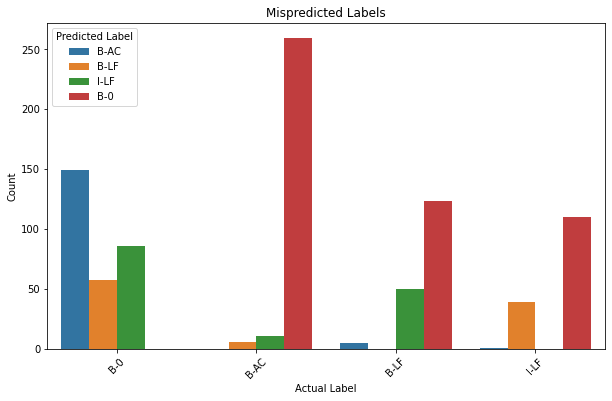

In [103]:
def get_mispredicted_pairs(confusion_matrix, labels):
    mispredicted_pairs = []

    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j and confusion_matrix[i, j] > 0:
                mispredicted_pairs.append((labels[i], labels[j], confusion_matrix[i, j]))

    return mispredicted_pairs

mispredicted_pairs = get_mispredicted_pairs(cm, labels)
for pair in mispredicted_pairs:
    print(f"Mispredicted: {pair[0]} as {pair[1]} - Count: {pair[2]}")


# Convert mispredicted pairs to DataFrame
mispredicted_df = pd.DataFrame(mispredicted_pairs, columns=['Actual', 'Predicted', 'Count'])

# Plot mispredicted pairs
plt.figure(figsize=(10, 6))
sns.barplot(x='Actual', y='Count', hue='Predicted', data=mispredicted_df)
plt.title('Mispredicted Labels')
plt.xlabel('Actual Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Predicted Label')
plt.show()


Epoch [1/10], Validation Loss: 0.4190, Test Accuracy: 0.3490
Epoch [2/10], Validation Loss: 0.4341, Test Accuracy: 0.3498
Epoch [3/10], Validation Loss: 0.4688, Test Accuracy: 0.3495
Epoch [4/10], Validation Loss: 0.4734, Test Accuracy: 0.3475
Epoch [5/10], Validation Loss: 0.5008, Test Accuracy: 0.3475
Epoch [6/10], Validation Loss: 0.5356, Test Accuracy: 0.3501
Epoch [7/10], Validation Loss: 0.5417, Test Accuracy: 0.3489
Epoch [8/10], Validation Loss: 0.5847, Test Accuracy: 0.3483
Epoch [9/10], Validation Loss: 0.6103, Test Accuracy: 0.3484
Epoch [10/10], Validation Loss: 0.6270, Test Accuracy: 0.3467


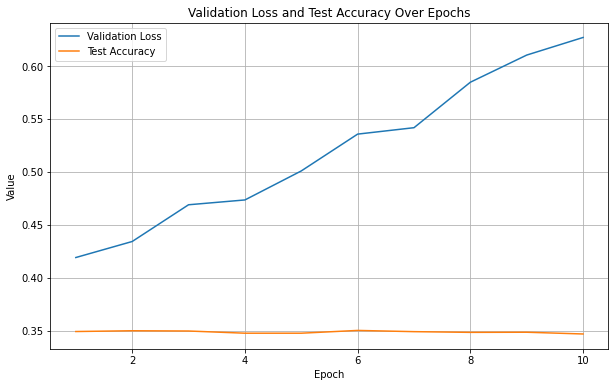

In [104]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Define the TransformerModel, convert_to_tensors, pad_collate, DataLoader, and model parameters as before...

# Lists to store validation loss and test accuracy for each epoch
validation_losses = []
test_accuracies = []

# Training and validating the model
for epoch in range(num_epochs):
    model.train()
    for input_ids, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(input_ids)
        loss = criterion(outputs.transpose(1, 2), labels)
        loss.backward()
        optimizer.step()

    # Model validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        total_correct = 0
        total_count = 0
        for input_ids, labels in val_loader:
            outputs = model(input_ids)
            val_loss += criterion(outputs.transpose(1, 2), labels).item()

        # Calculate validation loss
        validation_losses.append(val_loss / len(val_loader))

        # Calculate test accuracy
        correct = 0
        total = 0
        for input_ids, labels in test_loader:
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, dim=2)
            total += labels.size(0) * labels.size(1)
            correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        test_accuracies.append(accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {validation_losses[-1]:.4f}, Test Accuracy: {accuracy:.4f}')

# Plotting validation loss and test accuracy
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), validation_losses, label='Validation Loss')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Validation Loss and Test Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


# **Model Performance Evaluation:**

In [105]:
# Define metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Define model names
models = ['LSTM', 'Transformer']

# Define data for LSTM model
data_lstm = {
    'Model': ['LSTM'] * len(metrics),
    'Train': [train_accuracy_lstm, train_precision_lstm, train_recall_lstm, train_f1_lstm],
    'Validation': [val_accuracy_lstm, val_precision_lstm, val_recall_lstm, val_f1_lstm],
    'Test': [test_accuracy_lstm, test_precision_lstm, test_recall_lstm, test_f1_lstm]
}

# Define data for Transformer modelv
data_tnf = {
    'Model': ['Transformer'] * len(metrics),
    'Train': [train_accuracy_tnf, train_precision_tnf, train_recall_tnf, train_f1_tnf],
    'Validation': [val_accuracy_tnf, val_precision_tnf, val_recall_tnf, val_f1_tnf],
    'Test': [test_accuracy_tnf, test_precision_tnf, test_recall_tnf, test_f1_tnf]
}

# Create dataframes
df_lstm = pd.DataFrame(data_lstm, index=metrics)
df_tnf = pd.DataFrame(data_tnf, index=metrics)

# Concatenate dataframes
df = pd.concat([df_lstm, df_tnf])

# Display dataframe
df


,Model,Train,Validation,Test
Accuracy,LSTM,0.302505,0.251667,0.348314
Precision,LSTM,0.471763,0.376301,0.337314
Recall,LSTM,0.655147,0.497118,0.468876
F1-score,LSTM,0.502053,0.389867,0.361192
Accuracy,Transformer,0.301955,0.250867,0.350936
Precision,Transformer,0.564556,0.435834,0.424520
Recall,Transformer,0.666429,0.482196,0.495888
F1-score,Transformer,0.571890,0.407183,0.427476


In [106]:
print('Notebook executed successfully')

Notebook executed successfully
